# MDN Baseline: Ternary Phase Competition

Investigates whether a **Mixture Density Network (MDN) ensemble** can learn the
synthetic conditional distribution induced by the ternary phase-competition
benchmark

$$p_\star(y \mid x) = \sum_{\phi=1}^{N_\phi} \pi_\phi(x)\,\mathcal{N}\!\left(y;\,\mu_\phi(x),\,\sigma_\phi^2(x)\right)$$

where $x = [x_A, x_B, \text{proc}_1, \dots]$ specifies a ternary composition on
the simplex plus optional processing parameters.  Because the distribution is
**fully synthetic**, we have the exact true NLL as an oracle lower bound.  The
**calibration gap**

$$\Delta = \text{ensemble NLL} - \text{true NLL}$$

tells us precisely how well the model has learned — a diagnostic unavailable in
purely physical-system benchmarks.

In [49]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # replace with desired GPU
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

%matplotlib inline
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import jax
import jax.numpy as jnp
from jax import random

import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [51]:
%autoreload 2

_repo_root   = str(Path("../..").resolve())
_example_dir = str(Path(".").resolve())
for _p in [_repo_root, _example_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import optax
from jaxmix.archs import MLP, MDN, Ensemble
from jaxmix.trainers import MDNTrainer, MSETrainer, mdn_loss_func
from jaxmix.data_loaders import BatchedDataset

from ternary_phases import (
    make_phase_system,
    generate_dataset,
    log_prob,
    verify_phase_diagram,
)
from active_learning_utils import (
    plot_prediction_vs_truth,
    plot_epistemic_vs_aleatoric,
)
from examples.common_active_learning import evaluate_ensemble_nll

In [52]:
key = random.PRNGKey(42)
model_init_key = random.PRNGKey(67)

## Build the Phase System and Sample a Large Dataset

`make_phase_system` draws **all** parameters once from a fixed seed so the
distribution is reproducible.  We then call `generate_dataset` directly
with a large `N_TRAIN` so the baseline never has to worry about data
scarcity — the only thing left to measure is the model's calibration gap.

In [53]:
# ----- Distribution hyperparameters (match active_learning.ipynb / wandb runs) -----
N_PHASES      = 4
TAU_G         = 0.08
N_PROC_PARAMS = 6
C_MU_SCALE    = 6.0
SYSTEM_SEED   = 12

# ----- Dataset sizes -----
# Large fixed train + test sets — no active learning, the baseline gets to see
# enough samples that any remaining gap is calibration / capacity, not data.
N_TRAIN = 100_000
N_TEST  = 10_000

system = make_phase_system(
    seed=SYSTEM_SEED, n_phases=N_PHASES,
    tau_G=TAU_G, n_proc_params=N_PROC_PARAMS,
    c_mu_scale=C_MU_SCALE,
)

key, k_train, k_test = random.split(key, 3)
train_inputs, train_outputs = generate_dataset(system, k_train, N_TRAIN)
test_inputs,  test_outputs  = generate_dataset(system, k_test,  N_TEST)

true_nll = float(-jnp.mean(log_prob(system, test_outputs, test_inputs)))

# `data` dict matches the shape consumed by the simplex plot helpers below.
data = {"system": system, "test_data": (test_inputs, test_outputs), "true_nll": true_nll}

print(f"Number of phases       : {N_PHASES}")
print(f"Processing parameters  : {N_PROC_PARAMS}")
print(f"Input dimension        : {2 + N_PROC_PARAMS}  (x_A, x_B + proc)")
print(f"Output dimension       : 1  (scalar observable)")
print(f"Train samples          : {N_TRAIN:,}")
print(f"Test samples           : {N_TEST:,}")
print(f"True NLL (test set)    : {true_nll:.4f}")

Number of phases       : 4
Processing parameters  : 6
Input dimension        : 8  (x_A, x_B + proc)
Output dimension       : 1  (scalar observable)
Train samples          : 100,000
Test samples           : 10,000
True NLL (test set)    : 1.3301


## Verify the Phase Diagram

The simplex view shows: the dominant phase, the boundary band where two phases
compete (the multimodal regions), and the response mean of the dominant phase.

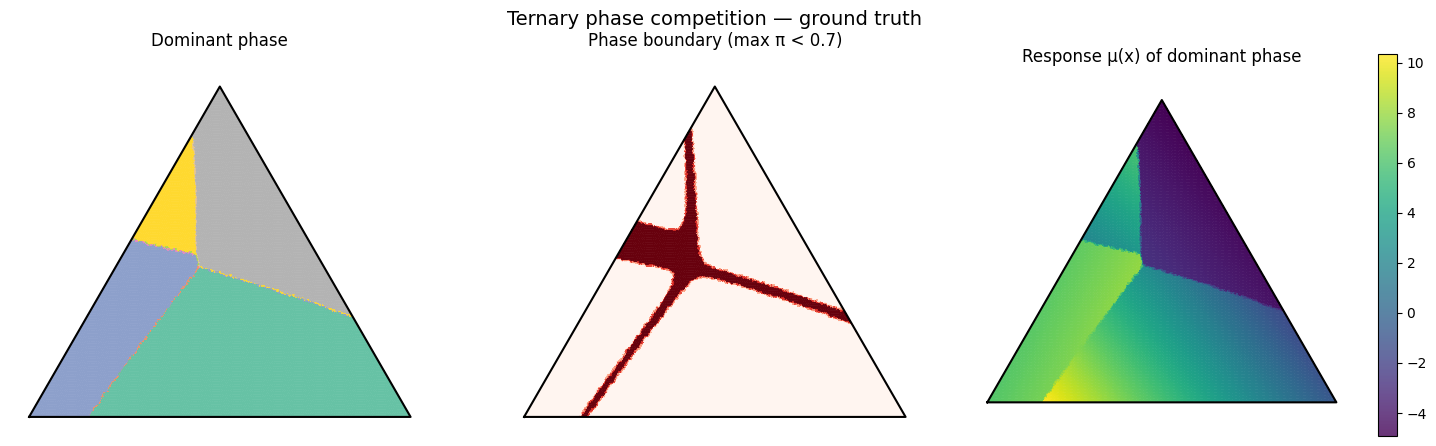

In [54]:
verify_phase_diagram(system);

## Assemble the Training Set

Wrap the generated arrays as `(inputs, outputs, weights)` tuples — the format
the trainers expect.  No pool / labelled split: this is a one-shot baseline.

In [55]:
train_weights = jnp.ones((train_inputs.shape[0], 1))
train_data    = (train_inputs, train_outputs, train_weights)

test_weights = jnp.ones((test_inputs.shape[0], 1))
test_data    = (test_inputs, test_outputs, test_weights)

print(f"Train : {train_inputs.shape}  ->  {train_outputs.shape}")
print(f"Test  : {test_inputs.shape}  ->  {test_outputs.shape}")
print(f"Output mean : {float(train_outputs.mean()):.5f}")
print(f"Output std  : {float(train_outputs.std()):.3f}")

Train : (100000, 8)  ->  (100000, 1)
Test  : (10000, 8)  ->  (10000, 1)
Output mean : 2.08138
Output std  : 4.583


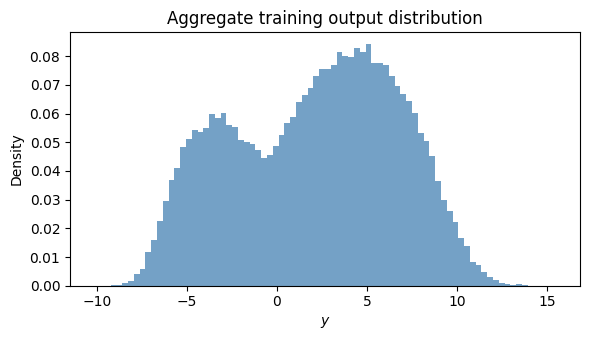

In [56]:
# Output marginal — should be (mildly) multimodal once aggregated across the simplex
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(np.asarray(train_outputs[:, 0]), bins=80, density=True,
        alpha=0.75, color="steelblue")
ax.set_xlabel("$y$")
ax.set_ylabel("Density")
ax.set_title("Aggregate training output distribution")
plt.tight_layout()
plt.show()

## Defining Model Architectures

In [57]:
ensemble_size = 8
num_mixtures  = 4    # = N_phases; the MDN has just enough capacity
hidden = 64
depth = 2
OUT_DIM = 1

# MSE Baseline
mse_base_arch = MLP(features=[hidden] * depth + [OUT_DIM])
mse_arch = Ensemble(mse_base_arch, ensemble_size)

# MDN
mdn_base_arch = MLP(features=[hidden] * depth)
mdn_backbone_arch = Ensemble(mdn_base_arch, ensemble_size)
MDN_arch = MDN(
    num_mixtures=num_mixtures,
    num_output_dims=OUT_DIM,
    backbone=mdn_backbone_arch,
    ensemble_size=ensemble_size,
)

# Shared LR schedule + optimiser (peak_lr lower than multimodal for variance-head stability)
num_linear_steps = 1_000
peak_lr          = 2e-4
lr = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0, end_value=peak_lr, transition_steps=num_linear_steps,
        ),
        optax.exponential_decay(
            init_value=peak_lr, transition_steps=2_000, decay_rate=0.9,
        ),
    ],
    boundaries=[num_linear_steps],
)
optimizer = optax.chain(
    optax.adaptive_grad_clip(0.1),
    optax.adamw(learning_rate=lr, weight_decay=5e-2),
)

## MSE Baseline Training

The MSE model minimises $\mathbb{E}[\|y - \hat{y}(x)\|^2]$.  Its optimal
predictor is the conditional mean $\sum_\phi \pi_\phi(x) \mu_\phi(x)$, which
collapses all phase information into a single point estimate per composition
and cannot capture any spread or multimodality.

In [58]:
init_batch = (train_inputs, train_outputs, train_weights)
key, subkey = random.split(model_init_key)
mse_model = MSETrainer(
    mse_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mse_model.tabulate())


                                        Ensemble Summary                                         
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module   ┃ inputs             ┃ outputs             ┃ params                   ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│              │ Ensemble │ float32[100000,8]  │ float32[8,100000,1] │                          │
├──────────────┼──────────┼────────────────────┼─────────────────────┼──────────────────────────┤
│ arch         │ MLP      │ float32[100000,8]  │ float32[100000,1]   │                          │
├──────────────┼──────────┼────────────────────┼─────────────────────┼──────────────────────────┤
│ arch/Dense_0 │ Dense    │ float32[100000,8]  │ float32[100000,64]  │ bias: float32[8,64]      │
│              │          │                    │                     │ kernel: float32[8,8,64]  │
│              │   

In [59]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=128)
mse_model.train(train_loader, nIter=60_000)

100%|██████████| 60000/60000 [00:43<00:00, 1377.25it/s, loss=0.12634584, grad_norm=0.11544784]  


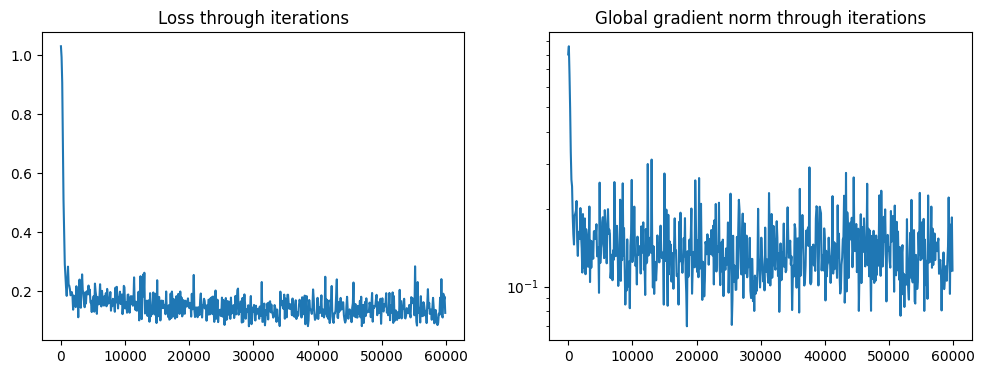

In [60]:
mse_model.plot_logs()

## MDN Training

The MDN maximises the log-likelihood of $p_\star(y|x)$ under its mixture model.
The ensemble NLL on the test set should approach the true NLL computed above.

In [61]:
key, subkey = random.split(model_init_key)
mdn_model = MDNTrainer(
    MDN_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mdn_model.tabulate())


                                                      MDN Summary                                                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                 ┃ outputs                 ┃ params                    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[100000,8]      │ - float32[8,100000,4,1] │                           │
│                       │              │                        │ - float32[8,100000,4,1] │                           │
│                       │              │                        │ - float32[8,100000,4,1] │                           │
├───────────────────────┼──────────────┼────────────────────────┼─────────────────────────┼───────────────────────────┤
│ backbone              │ Ensemble     

In [62]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=128)
mdn_model.train(train_loader, nIter=80_000)

100%|██████████| 80000/80000 [01:04<00:00, 1246.26it/s, loss=-0.18619782, grad_norm=2.252314]   


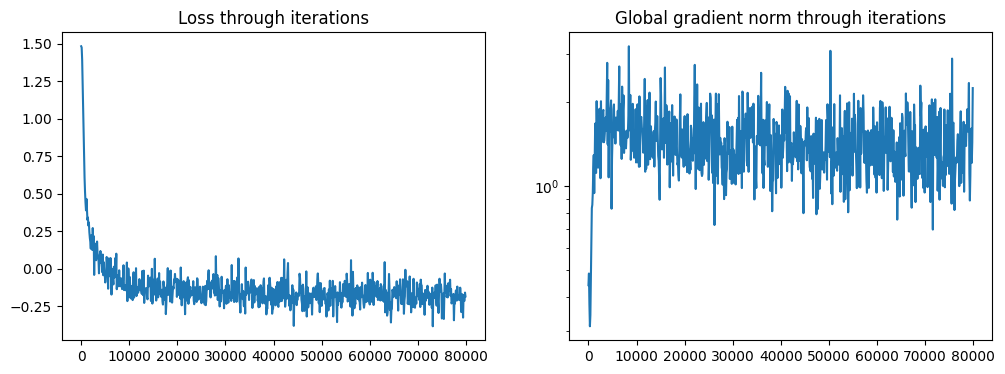

In [63]:
mdn_model.plot_logs()

In [64]:
# MDN ensemble NLL on test set
mdn_nll = evaluate_ensemble_nll(mdn_model, test_inputs, test_outputs)
gap     = mdn_nll - true_nll

# MSE test loss
mse_preds = mse_model.apply(mse_model.params, test_inputs)  # (E, N, 1)
mse_mean_pred = float(mse_preds.mean(axis=0).mean())
mse_test_loss = float(((mse_preds.mean(axis=0) - test_outputs) ** 2).mean())

print(f"True NLL (oracle floor) : {true_nll:.4f}")
print(f"MDN ensemble NLL        : {mdn_nll:.4f}")
print(f"Calibration gap  Δ      : {gap:.4f}  (MDN NLL − true NLL)")
print()
print(f"MSE model mean output   : {mse_mean_pred:.5f}")
print(f"MSE test loss           : {mse_test_loss:.4f}  (≈ output variance)")

True NLL (oracle floor) : 1.3301
MDN ensemble NLL        : 1.3353
Calibration gap  Δ      : 0.0051  (MDN NLL − true NLL)

MSE model mean output   : 2.07101
MSE test loss           : 2.8518  (≈ output variance)


## Single-Gaussian (K=1) MDN Baseline

Intermediate between MSE and the full MDN: an `MDNTrainer` with `num_mixtures=1`
is a Gaussian-NLL model.  It captures the conditional **mean and variance** but
is structurally incapable of representing multimodality — a useful diagnostic for
how much of the MDN's advantage comes from modelling spread vs. modelling modes.

In [65]:
MDN_single_arch = MDN(
    num_mixtures=1,
    num_output_dims=OUT_DIM,
    backbone=mdn_backbone_arch,
    ensemble_size=ensemble_size,
)

key, subkey = random.split(model_init_key)
mdn_single_model = MDNTrainer(
    MDN_single_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mdn_single_model.tabulate())


                                                      MDN Summary                                                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                 ┃ outputs                 ┃ params                    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[100000,8]      │ - float32[8,100000,1,1] │                           │
│                       │              │                        │ - float32[8,100000,1,1] │                           │
│                       │              │                        │ - float32[8,100000,1,1] │                           │
├───────────────────────┼──────────────┼────────────────────────┼─────────────────────────┼───────────────────────────┤
│ backbone              │ Ensemble     

100%|██████████| 80000/80000 [01:03<00:00, 1266.61it/s, loss=0.36550388, grad_norm=1.0961629] 


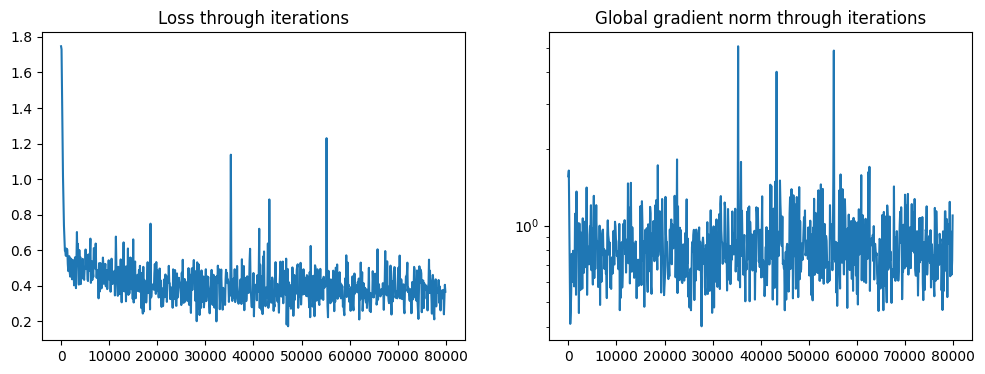

In [66]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=128)
mdn_single_model.train(train_loader, nIter=80000)
mdn_single_model.plot_logs()

In [67]:
mdn_single_nll = evaluate_ensemble_nll(mdn_single_model, test_inputs, test_outputs)

print(f"True NLL (oracle floor)     : {true_nll:.4f}")
print(f"MDN (K={num_mixtures}) ensemble NLL   : {mdn_nll:.4f}")
print(f"MDN (K=1) ensemble NLL        : {mdn_single_nll:.4f}")
gap_single = mdn_single_nll - true_nll
print(f"Calibration gap Δ (single-G) : {gap_single:.4f}")

True NLL (oracle floor)     : 1.3301
MDN (K=4) ensemble NLL   : 1.3353
MDN (K=1) ensemble NLL        : 1.8841
Calibration gap Δ (single-G) : 0.5540


## Visual Comparison

### 1. NLL summary bar chart

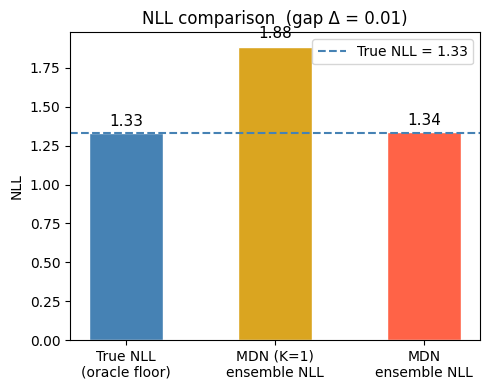

In [68]:
labels = ["True NLL\n(oracle floor)", "MDN (K=1)\nensemble NLL", "MDN\nensemble NLL"]
values = [true_nll, mdn_single_nll, mdn_nll]
colors = ["steelblue", "goldenrod", "tomato"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)
ax.axhline(true_nll, color="steelblue", linestyle="--", linewidth=1.5,
           label=f"True NLL = {true_nll:.2f}")
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02 * abs(bar.get_height()),
        f"{val:.2f}", ha="center", va="bottom", fontsize=11,
    )
ax.set_ylabel("NLL")
ax.set_title(f"NLL comparison  (gap Δ = {gap:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

### 2. Predicted vs true conditional mean on the simplex

Side-by-side simplex heatmaps of $E_\star[Y|x]$ vs the MDN's $E[Y|x]$ vs the
residual.  Processing parameters are pinned to zero.

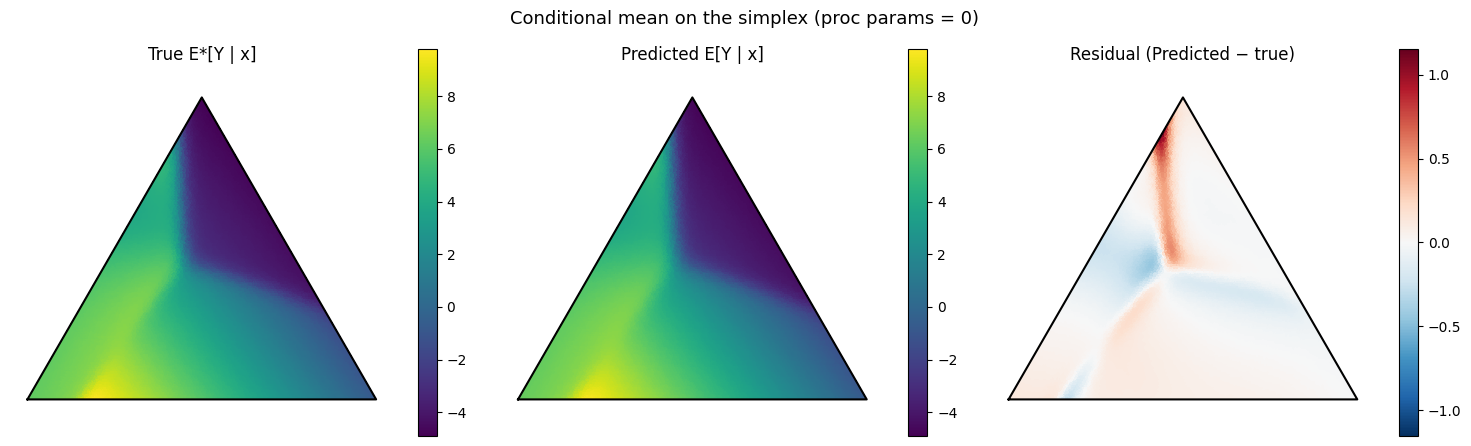

In [69]:
plot_prediction_vs_truth(mdn_model, data);

### 2b. MSE predicted mean on the simplex

Same panels for the MSE model.  Because MSE minimises squared error it
converges to the conditional mean $\sum_\phi \pi_\phi(x)\,\mu_\phi(x)$ —
it will look like a smoothed version of the true map with **no awareness**
of the phase structure or multimodality.  The MDN version above should
track phase boundaries much more sharply.

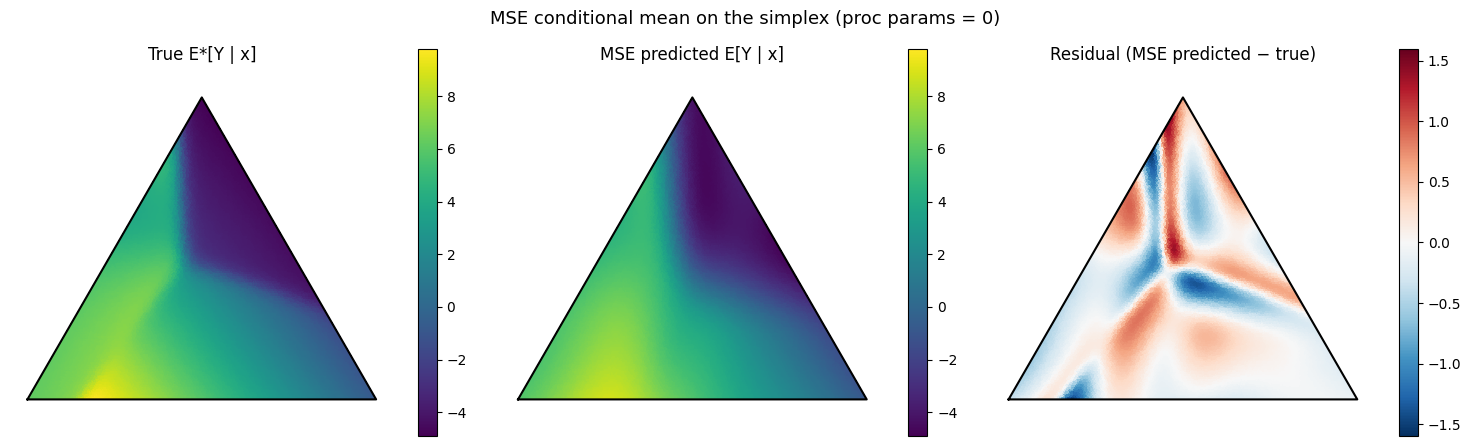

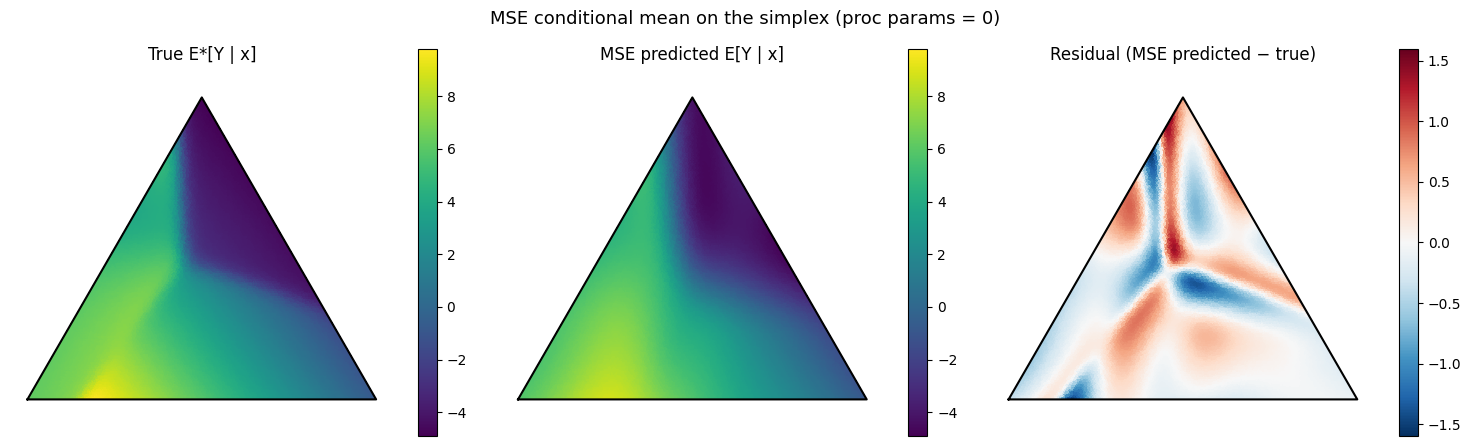

In [70]:
from active_learning_utils import simplex_grid_inputs, plot_mean_vs_truth_on_simplex

x3, x_grid = simplex_grid_inputs(system, n_grid=120)

mse_grid_preds = mse_model.apply(mse_model.params, x_grid)  # (E, B, 1)
mse_pred_mean = mse_grid_preds.mean(axis=0)[..., 0]

plot_mean_vs_truth_on_simplex(
    system, mse_pred_mean, x3, label="MSE predicted",
    suptitle="MSE conditional mean on the simplex (proc params = 0)",
)

### 2c. MDN (K=1) predicted mean on the simplex

Same panels for the single-Gaussian MDN.  Because it can only place one Gaussian per x,
it cannot express phase competition — its predicted mean should look like a smoothed
version of the true map, similar to MSE.

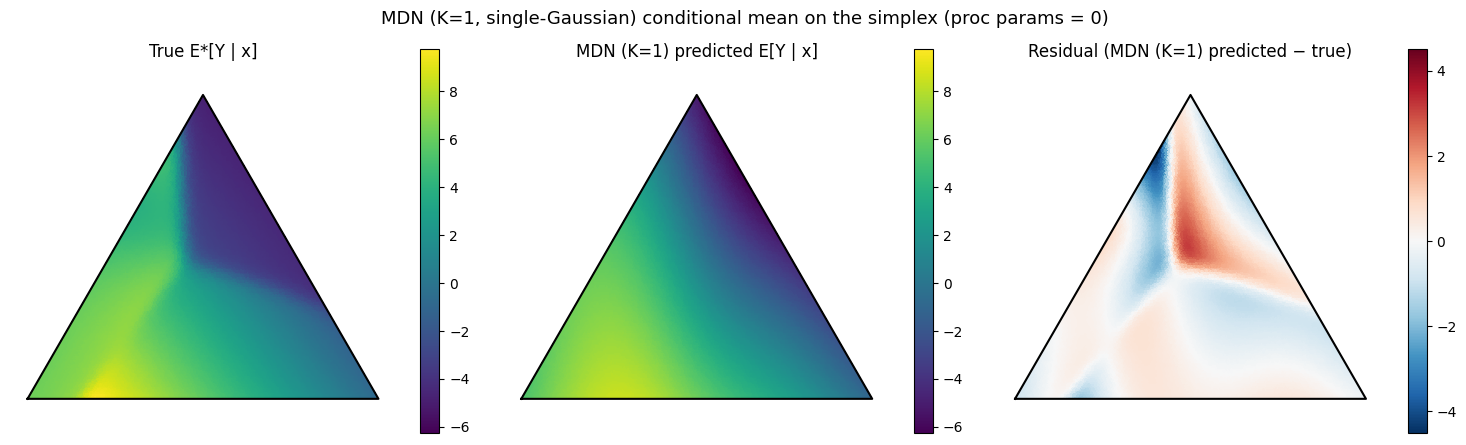

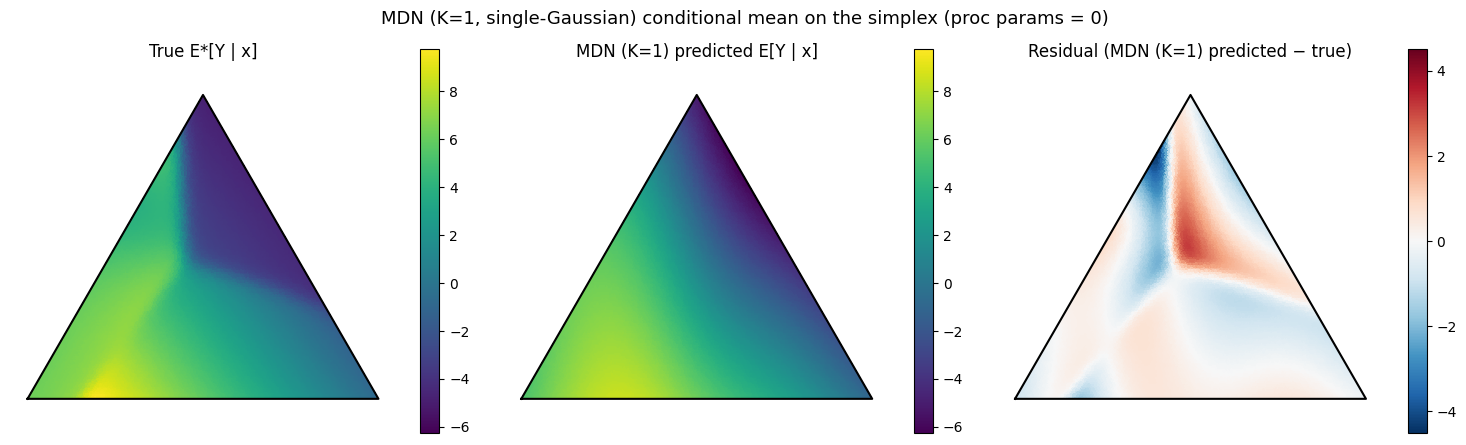

In [71]:
lw_s, mu_s, _vs = mdn_single_model.apply(mdn_single_model.params, x_grid)
w_s = jax.nn.softmax(lw_s, axis=-2)
per_member_mean_s = jnp.sum(w_s * mu_s, axis=-2)
single_pred_mean = jnp.mean(per_member_mean_s, axis=0)[..., 0]

plot_mean_vs_truth_on_simplex(
    system, single_pred_mean, x3, label="MDN (K=1) predicted",
    suptitle="MDN (K=1, single-Gaussian) conditional mean on the simplex (proc params = 0)",
)

### 3. Epistemic vs aleatoric variance on the simplex

A well-trained MDN should show epistemic variance concentrated on phase
boundaries (where the mixture is multimodal) and aleatoric variance tracking
the noise structure independently — two distinct maps.

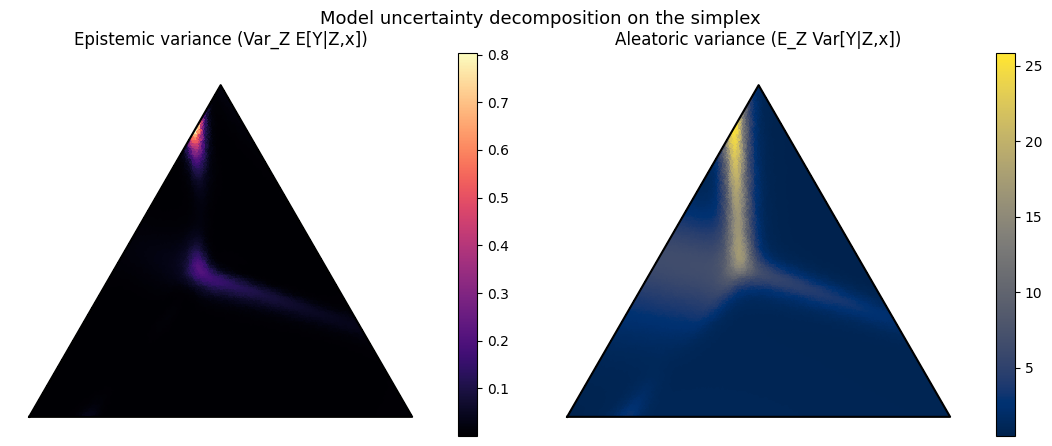

In [72]:
plot_epistemic_vs_aleatoric(mdn_model, data);